In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import load_and_preprocess_data, vectorize_text
from model_utils import evaluate_model

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42

## Load and Preprocess Phishing Data

The phishing dataset contains:
- `text_combined`: The email content (already preprocessed/combined)
- `label`: Binary label (1 = phishing, 0 = safe/legitimate)

In [3]:
# Load and preprocess the phishing email data
X, y, df = load_and_preprocess_data(
    '../data/phishing_email.csv',
    text_columns=['text_combined'],
    target_column='label',
    positive_class=1, # 1 = phishing
    combine_text=False # Only one text column
)

Loading data from ../data/phishing_email.csv...
Dataset shape: (82486, 2)

Column names: ['text_combined', 'label']

First few rows:
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0

Using single text column: text_combined

Class distribution:
Negative/Ham (0): 39595 (48.00%)
Positive/Spam (1): 42891 (52.00%)


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y # Maintain class distribution in splits
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 65988
Test set size: 16498


In [5]:
# Vectorize text using TF-IDF
X_train_vec, X_test_vec, vectorizer = vectorize_text(
    X_train, X_test,
    method='tfidf',
    max_features=5000,
    min_df=2, # Ignore terms that appear in fewer than 2 documents
    ngram_range=(1, 2), # Use unigrams and bigrams
    stop_words='english' # Remove common English filler words
)

Vectorizing text using TFIDF...
Training set shape: (65988, 5000)
Test set shape: (16498, 5000)
Vocabulary size: 5000


## Train SVM Classifier

In [6]:
# Initialize and train SVM classifier
# Using linear kernel to allow for feature importance inspection
# probability=True is needed for predict_proba in the testing section
svm_classifier = SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)
print("Training SVM classifier... (this may take a moment)")
svm_classifier.fit(X_train_vec, y_train)

Training SVM classifier... (this may take a moment)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
# Predict on training set
y_train_pred = svm_classifier.predict(X_train_vec)

# Predict on test set
y_test_pred = svm_classifier.predict(X_test_vec)

## Model Evaluation

In [8]:
# Evaluate on training set
train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")

# Evaluate on test set
test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

# Print detailed classification report
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Safe', 'Phishing']))

Training Set Metrics:
Accuracy:  0.9902
Precision: 0.9881
Recall:    0.9932
F1-Score:  0.9906
Test Set Metrics:
Accuracy:  0.9843
Precision: 0.9830
Recall:    0.9868
F1-Score:  0.9849

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

        Safe       0.99      0.98      0.98      7919
    Phishing       0.98      0.99      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



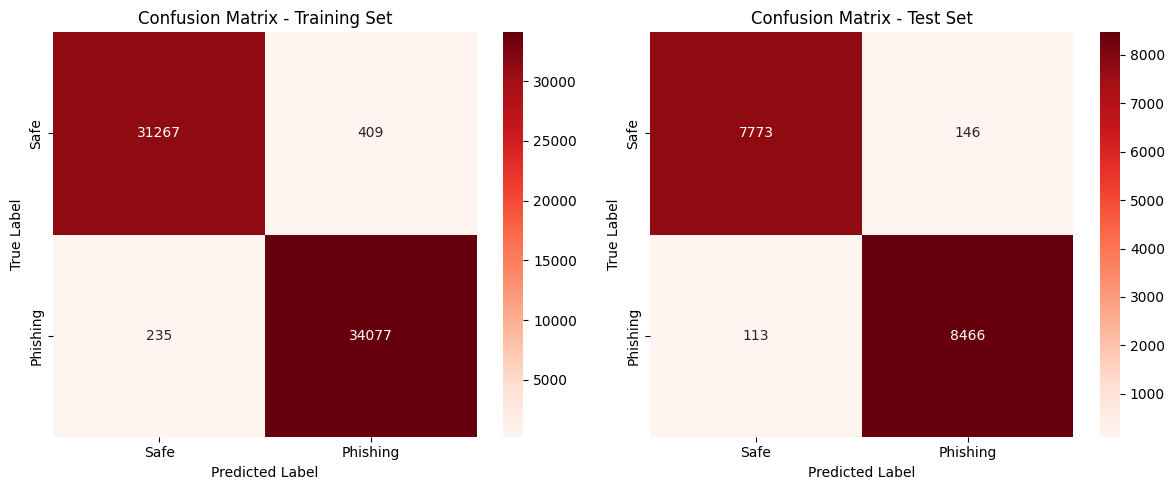

In [9]:
# Visualize with confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Test set confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Feature Analysis

Examine which words/features are most indicative of phishing vs. safe emails.
For Linear SVM, positive coefficients indicate phishing, negative indicate safe.

In [10]:
# Show top features for each class
# For Linear SVM, we can look at the coefficients
# Positive coefficients -> Phishing (Class 1)
# Negative coefficients -> Safe (Class 0)

def get_top_features_svm(vectorizer, classifier, n=20):
    """Get top features (words) for each class based on SVM coefficients."""
    feature_names = vectorizer.get_feature_names_out()
    
    # Get coefficients (shape is [1, n_features] for binary classification)
    # Convert sparse matrix to dense array if necessary
    if hasattr(classifier.coef_, 'toarray'):
        coefs = classifier.coef_.toarray()[0]
    else:
        coefs = classifier.coef_[0]
    
    # Top features for Safe (most negative coefficients)
    safe_indices = coefs.argsort()[:n]
    top_safe = [(feature_names[i], coefs[i]) for i in safe_indices]
    
    # Top features for Phishing (most positive coefficients)
    phishing_indices = coefs.argsort()[-n:][::-1]
    top_phishing = [(feature_names[i], coefs[i]) for i in phishing_indices]
    
    return top_safe, top_phishing

top_safe, top_phishing = get_top_features_svm(vectorizer, svm_classifier, n=15)

print("Top 15 Safe Email Features (Negative Coefficients):")
for i, (word, coef) in enumerate(top_safe, 1):
    print(f"{i:2d}. {word:25s} (coef: {coef:.4f})")

print("\nTop 15 Phishing Email Features (Positive Coefficients):")
for i, (word, coef) in enumerate(top_phishing, 1):
    print(f"{i:2d}. {word:25s} (coef: {coef:.4f})")

Top 15 Safe Email Features (Negative Coefficients):
 1. enron                     (coef: -6.5099)
 2. wrote                     (coef: -6.3020)
 3. thanks                    (coef: -5.0224)
 4. vince                     (coef: -4.3027)
 5. uai                       (coef: -4.1848)
 6. opensuse                  (coef: -4.1754)
 7. pm                        (coef: -3.8978)
 8. 713                       (coef: -3.4496)
 9. fork                      (coef: -3.4362)
10. 1300                      (coef: -3.3674)
11. tony                      (coef: -3.3437)
12. louise                    (coef: -3.1940)
13. 2008                      (coef: -3.1721)
14. edu                       (coef: -3.1481)
15. daren                     (coef: -3.0702)

Top 15 Phishing Email Features (Positive Coefficients):
 1. josemonkeyorg             (coef: 4.2654)
 2. 2004                      (coef: 3.8664)
 3. 2016                      (coef: 3.2003)
 4. http                      (coef: 3.1259)
 5. remove           

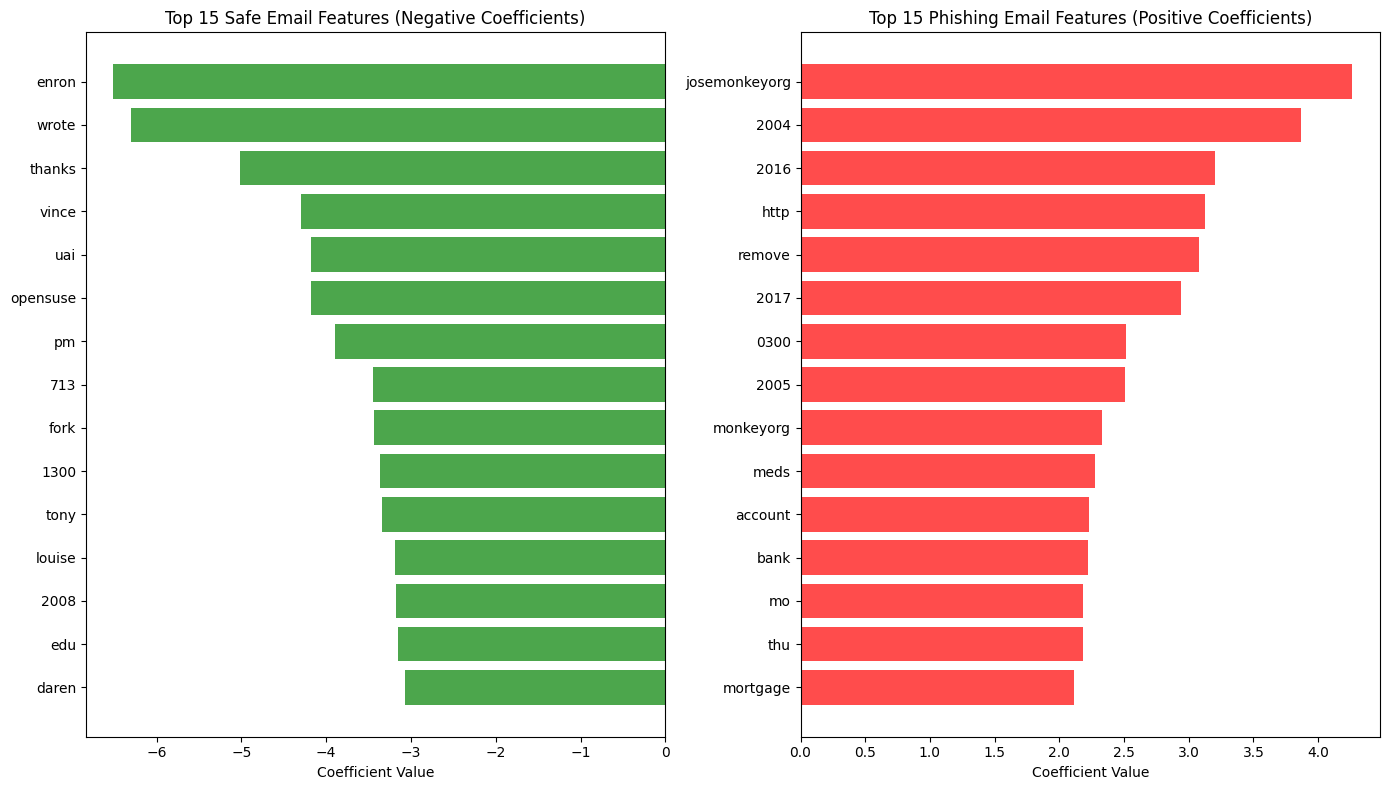

In [11]:
# Visualize top features as horizontal bar charts

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top Safe features (negative coefficients)
safe_words = [word for word, _ in top_safe[:15]]
safe_coefs = [coef for _, coef in top_safe[:15]]
axes[0].barh(safe_words[::-1], safe_coefs[::-1], color='green', alpha=0.7)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 15 Safe Email Features (Negative Coefficients)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Top Phishing features (positive coefficients)
phishing_words = [word for word, _ in top_phishing[:15]]
phishing_coefs = [coef for _, coef in top_phishing[:15]]
axes[1].barh(phishing_words[::-1], phishing_coefs[::-1], color='red', alpha=0.7)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Top 15 Phishing Email Features (Positive Coefficients)')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## Test on New Samples

Test the classifier on some example emails to see how it performs.

In [12]:
def predict_phishing(text, vectorizer, classifier):
    """Predict whether an email is a phishing attempt."""
    text_vec = vectorizer.transform([text])
    prediction = classifier.predict(text_vec)[0]
    probability = classifier.predict_proba(text_vec)[0]
    
    label = "PHISHING" if prediction == 1 else "SAFE"
    confidence = probability[prediction]
    
    return label, confidence, probability

# Test examples - mix of phishing-like and legitimate emails
test_examples = [
    # Legitimate business emails
    "Hi Team, Please find attached the quarterly report. Let me know if you have any questions. Best regards, John",
    "Meeting reminder: Project sync tomorrow at 2pm in Conference Room B. Agenda attached.",
    
    # Phishing-like emails
    "URGENT: Your account has been compromised! Click here immediately to verify your identity and secure your account.",
    "Congratulations! You have been selected for a $1,000,000 prize. Click the link below to claim your reward now!",
    "Your PayPal account has been limited. Please update your information immediately to avoid suspension. Click here to verify.",
    "Dear Customer, We detected unusual activity on your bank account. Please confirm your identity by providing your SSN and password."
]

for i, example in enumerate(test_examples, 1):
    label, confidence, probs = predict_phishing(example, vectorizer, svm_classifier)
    
    print(f"\nExample {i}:")
    print(f"Text: {example[:100]}..." if len(example) > 100 else f"Text: {example}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Probabilities - Safe: {probs[0]:.2%}, Phishing: {probs[1]:.2%}")


Example 1:
Text: Hi Team, Please find attached the quarterly report. Let me know if you have any questions. Best rega...
Prediction: SAFE
Confidence: 99.98%
Probabilities - Safe: 99.98%, Phishing: 0.02%

Example 2:
Text: Meeting reminder: Project sync tomorrow at 2pm in Conference Room B. Agenda attached.
Prediction: SAFE
Confidence: 99.99%
Probabilities - Safe: 99.99%, Phishing: 0.01%

Example 3:
Text: URGENT: Your account has been compromised! Click here immediately to verify your identity and secure...
Prediction: PHISHING
Confidence: 100.00%
Probabilities - Safe: 0.00%, Phishing: 100.00%

Example 4:
Text: Congratulations! You have been selected for a $1,000,000 prize. Click the link below to claim your r...
Prediction: PHISHING
Confidence: 84.85%
Probabilities - Safe: 15.15%, Phishing: 84.85%

Example 5:
Text: Your PayPal account has been limited. Please update your information immediately to avoid suspension...
Prediction: PHISHING
Confidence: 100.00%
Probabilities - Safe: 0.00%,

## Save Model and Vectorizer

Save the trained model and vectorizer for use in the pipeline notebook.

In [13]:
import joblib
import os

# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the model and vectorizer
joblib.dump(svm_classifier, os.path.join(models_dir, 'phishing_svm_model.joblib'))
joblib.dump(vectorizer, os.path.join(models_dir, 'phishing_svm_vectorizer.joblib'))

print(f"Model saved to {models_dir}/phishing_svm_model.joblib")
print(f"Vectorizer saved to {models_dir}/phishing_svm_vectorizer.joblib")

Model saved to ../models/phishing_svm_model.joblib
Vectorizer saved to ../models/phishing_svm_vectorizer.joblib
